# Subject-wise params from the bauer v0.4.0 (`bauerV4`) re-fit

Pulls subject-wise point estimates (posterior means) out of the new choice/DDM/RDM traces fit
with `bauer` **v0.4.0** by the collaborator's `dyscalculic_ddm` repo (see `README.md` in this
folder), and saves them to `derivatives/phenotype/` for use alongside the other behavioral
measures (cf. `behavior_general/measures_registry.py`, `utils/data_02.py::get_all_behavior`).
Named `bauerV4` (not `bauer-1`...`bauer-6` like the older `utils_02.py::build_model` labels, and
not `ddm`/`choice`, since this naming is about the *fitting procedure* — bauer v0.4.0's cell-means
group regression — not the response layer, which could be the static choice model, DDM, or RDM).

These traces use a **cell-means** group design (`random_regressors={p: '0 + C(group)'}`), not the reference-cell (`Intercept` + offset) design of our older `utils_02.py::build_model` models. Per-subject, only the regressor level matching their *actual* group is informed by their data — the other level is just the population prior (verified below by comparing posterior SDs) — so extraction needs `get_subwise_params_cellmeans` (added to `utils_02.py`), not the older `get_subwise_params`.

Run this with the `dyscalculic_ddm` conda env / kernel (needs `bauer` v0.4.0 + `arviz`; see `/home/ubuntu/git/dyscalculic_ddm/notes/sciencecloud_choice_fit_howto.md`).

In [1]:
import os.path as op
import os
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

from utils_02 import get_subwise_params_cellmeans

## Config

The traces live on `/mnt_03` (group share mount), not under the usual `bids_folder` tree — they're too large to keep alongside the rest of `derivatives/` (see `README.md`). Phenotype CSVs are still written into the normal `derivatives/phenotype/` location so they get picked up by the usual loaders.

In [2]:
bids_folder = '/mnt_03/ds-dnumrisk'
model_label = 'choice_pm_hn'  # matches collect_overview.py's MODELS / the *_trace.nc filename

trace_fn = op.join(bids_folder, 'derivatives', 'cogmodels_magjudge', f'model-{model_label}_trace.nc')
phenotype_folder = op.join(bids_folder, 'derivatives', 'phenotype')

idata = az.from_netcdf(trace_fn)
print(list(idata.posterior.data_vars))

['perceptual_noise_sd_mu', 'perceptual_noise_sd_offset', 'memory_noise_sd_mu', 'memory_noise_sd_offset', 'perceptual_noise_sd_sd', 'memory_noise_sd_sd', 'perceptual_noise_sd', 'memory_noise_sd']


## Group mapping

Re-derive `subject -> group label` from our own participants table (not from the collaborator's csv) so this stays the source of truth. Cross-checked: `group==0` is `control`, `group==1` is `dyscalc` here, matching the `C(group)[control]` / `C(group)[dyscalc]` regressor labels in the trace - **re-check this if you fit a new model/trace**, the README flags this exact mapping as easy to get silently backwards.

In [3]:
df_participants = pd.read_csv(op.join(bids_folder, 'add_tables', 'subjects_recruit_scan_scanned-final.csv'), header=0)
df_participants = (df_participants
                   .loc[:, ['subject ID', 'group']]
                   .rename(columns={'subject ID': 'subject'})
                   .dropna()
                   .astype({'subject': int, 'group': int})
                   .set_index('subject'))

group_label = {0: 'control', 1: 'dyscalc'}
group_map = df_participants['group'].map(group_label).to_dict()

# sanity check against the trace's own subject/regressor coords
trace_subjects = set(idata.posterior['subject'].values)
missing = trace_subjects - set(group_map)
assert not missing, f'no group label for subjects: {missing}'

### Confirm the cell-means design: own-group regressor should be data-informed (tighter), other should look like the prior (wider)

In [4]:
check_sub = idata.posterior['subject'].values[0]
own_group = group_map[check_sub]
other_group = 'dyscalc' if own_group == 'control' else 'control'
stds = idata.posterior['perceptual_noise_sd'].sel(subject=check_sub).std(dim=['chain', 'draw']).to_pandas()
print(f'subject {check_sub} (group={own_group}):')
print(stds)
assert stds[f'C(group)[{own_group}]'] < stds[f'C(group)[{other_group}]'], 'own-group regressor should be tighter (data-informed)'

subject 1 (group=control):
perceptual_noise_sd_regressors
C(group)[control]    0.290379
C(group)[dyscalc]    0.419723
Name: perceptual_noise_sd, dtype: float64


## Extract subject-wise params and save to phenotype

In [5]:
param_names = ['perceptual_noise_sd', 'memory_noise_sd']

df_params = pd.concat([get_subwise_params_cellmeans(idata, p, group_map) for p in param_names], axis=1)
df_params['group'] = df_params.index.map(df_participants['group'])
df_params.head()

,perceptual_noise_sd,memory_noise_sd,group
subject,,,
1,0.087726,0.112281,0
2,0.102766,0.170494,1
3,0.156065,0.136644,0
4,0.061159,0.151653,1
5,0.130951,0.120729,0


In [6]:
out_fn = op.join(phenotype_folder, f'magjudge_bauerV4-{model_label}_sds.csv')
df_params.to_csv(out_fn)
print(f'saved to {out_fn}')

saved to /mnt_03/ds-dnumrisk/derivatives/phenotype/magjudge_bauerV4-choice_pm_hn_sds.csv


## Syncing to your local `bids_folder/derivatives/phenotype`

Nothing in this repo automates that pull today — there's no cron/rsync job set up anywhere in `numrisk`. The CSVs written above are tiny, so a one-off `rsync` from your Mac (it has to be pulled *to* the Mac; this sciencecloud box can't push to it) is simplest:

```bash
rsync -avz sciencecloud:/mnt_03/ds-dnumrisk/derivatives/phenotype/magjudge_bauerV4-choice_pm_hn_sds.csv \
    /Users/mrenke/data/ds-dnumrisk/derivatives/phenotype/
```

If you want this to happen automatically whenever a new fit lands, that has to run as a **scheduled job on your Mac** (`launchd`/cron calling the same `rsync` line) since this environment has no way to reach your local machine on its own — happy to set that up if you want it, just say so.

## Group effects

TODO: plot/compare `perceptual_noise_sd` and `memory_noise_sd` between `control` and `dyscalc`.

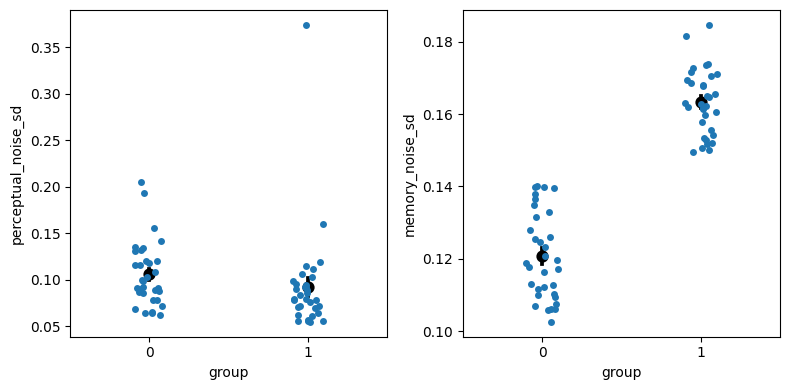

In [7]:
fig, axes = plt.subplots(1, len(param_names), figsize=(4 * len(param_names), 4))
for ax, p in zip(axes, param_names):
    sns.stripplot(data=df_params.reset_index(), x='group', y=p, ax=ax)
    sns.pointplot(data=df_params.reset_index(), x='group', y=p, ax=ax, color='k', errorbar='se', linestyle='none')
plt.tight_layout()